
# Round 3 Analysis Notebook

This notebook loads the round 3 historical data, reproduces the main market structure, and saves figures into `round_3/graphs/` while showing them inline.

## Scope

Round 3 introduces two delta-1 products and 10 call-style vouchers on `VELVETFRUIT_EXTRACT`.

- `HYDROGEL_PACK`
- `VELVETFRUIT_EXTRACT`
- `VEV_4000`, `VEV_4500`, `VEV_5000`, `VEV_5100`, `VEV_5200`, `VEV_5300`, `VEV_5400`, `VEV_5500`, `VEV_6000`, `VEV_6500`

Historical data provided here contains 3 days, 10,000 timestamps per day, and 12 products per timestamp.

## High-level findings

- `HYDROGEL_PACK` looks like a wide-spread, mean-reverting delta-1 market. Average top-of-book spread is about **15.7**, average top depth is **12.4**, lag-1 return autocorrelation is **-0.129**, and top-level imbalance has useful predictive power with correlation **0.299** to the next mid-price move.
- `VELVETFRUIT_EXTRACT` is materially tighter and deeper: spread about **5.0**, top depth about **37.8**, lag-1 autocorrelation **-0.158**, and imbalance-to-next-move correlation **0.281**.
- The voucher surface is clean in a no-arbitrage sense: across all timestamps it stays **monotone decreasing in strike** and **convex in strike**.
- A sampled Black-Scholes fit gives a remarkably stable implied vol regime: **day 0: 0.231 +/- 0.004, day 1: 0.233 +/- 0.005, day 2: 0.231 +/- 0.007**. That suggests the market is pricing vouchers off a fairly coherent rule rather than ad hoc noise.
- Relative to that fitted surface, the main persistent dislocations are: **`VEV_5400` cheap**, **`VEV_5300` rich**, **`VEV_5500` rich**, and `VEV_6000` / `VEV_6500` effectively pinned to a floor near **0.5**.
- Liquidity is very uneven across strikes. The least informative market-trade series are **VEV_4500 (1 trades), VEV_5000 (1 trades), VEV_5100 (1 trades), VEV_5200 (18 trades)**. For those strikes, quotes matter more than historical prints.
- For the manual challenge, under the interpretation that the penalty scales expected PnL when your second bid is below the market average, the robust optimum is roughly **(750, 835)** if the crowd average second bid is not above 835. Sensitivity examples: **avg b2=800: best (750, 835) -> 4165.0; avg b2=840: best (755, 840) -> 4165.0; avg b2=880: best (775, 880) -> 3885.0**.

## Important assumption

The wiki says the historical days correspond to earlier rounds with time-to-expiry decreasing by one day per round. I treat the three files here as **TTE = 8d, 7d, 6d** for historical days **0, 1, 2** respectively. If IMC intended a different mapping, the implied-vol section should be adjusted accordingly.


In [1]:

from pathlib import Path
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display, Markdown, Image

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

NOTEBOOK_DIR = Path.cwd()
ROUND_DIR = NOTEBOOK_DIR.parent
RAW_DIR = ROUND_DIR / 'raw'
GRAPHS_DIR = ROUND_DIR / 'graphs'
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FIGURES = True

T_MAP = {0: 8 / 365, 1: 7 / 365, 2: 6 / 365}
SIGMA_GRID = np.linspace(0.01, 1.5, 400)


def savefig(name: str):
    if SAVE_FIGURES:
        plt.savefig(GRAPHS_DIR / name, dpi=160, bbox_inches='tight')


def bs_matrix(S: float, K: np.ndarray, T: float, sigmas: np.ndarray) -> np.ndarray:
    sig = sigmas[:, None]
    K = K[None, :]
    d1 = (np.log(S / K) + 0.5 * sig**2 * T) / (sig * np.sqrt(T))
    d2 = d1 - sig * np.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)


def manual_expected_pnl(b1: int, b2: int, avg_b2: int) -> float:
    reserves = np.arange(670, 921, 5)
    penalty = 1.0 if b2 >= avg_b2 else ((920 - avg_b2) / (920 - b2)) ** 3
    pnl = 0.0
    for r in reserves:
        if b1 > r:
            pnl += 920 - b1
        elif b2 > r:
            pnl += (920 - b2) * penalty
    return pnl


In [2]:

price_files = sorted(RAW_DIR.glob('prices_round_3_day_*.csv'))
trade_files = sorted(RAW_DIR.glob('trades_round_3_day_*.csv'))

prices = pd.concat([
    pd.read_csv(p, sep=';').assign(hist_day=int(p.stem.split('_')[-1]))
    for p in price_files
], ignore_index=True)
trades = pd.concat([
    pd.read_csv(p, sep=';').assign(hist_day=int(p.stem.split('_')[-1]))
    for p in trade_files
], ignore_index=True)

prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']
prices['top_depth'] = (prices['bid_volume_1'] + prices['ask_volume_1']) / 2

vev = prices[prices['product'] == 'VELVETFRUIT_EXTRACT'][['hist_day', 'timestamp', 'mid_price']].rename(columns={'mid_price': 'S'})
options = prices[prices['product'].str.startswith('VEV_')].copy()
options['strike'] = options['product'].str.split('_').str[1].astype(int)
options = options.merge(vev, on=['hist_day', 'timestamp'], how='left')
options['intrinsic'] = np.maximum(options['S'] - options['strike'], 0)
options['extrinsic'] = options['mid_price'] - options['intrinsic']
options['moneyness'] = options['S'] / options['strike']

file_overview = pd.DataFrame({
    'file': [p.name for p in price_files + trade_files],
    'rows': [pd.read_csv(p, sep=';').shape[0] for p in price_files + trade_files],
})

display(file_overview)
print('Products:', ', '.join(sorted(prices['product'].unique())))
print('Price timestamps per day:', prices.groupby('hist_day')['timestamp'].nunique().to_dict())
print('Trade timestamps per day:', trades.groupby('hist_day')['timestamp'].nunique().to_dict())


,file,rows
0,prices_round_3_day_0.csv,120000
1,prices_round_3_day_1.csv,120000
2,prices_round_3_day_2.csv,120000
3,trades_round_3_day_0.csv,1308
4,trades_round_3_day_1.csv,1407
5,trades_round_3_day_2.csv,1333


Products: HYDROGEL_PACK, VELVETFRUIT_EXTRACT, VEV_4000, VEV_4500, VEV_5000, VEV_5100, VEV_5200, VEV_5300, VEV_5400, VEV_5500, VEV_6000, VEV_6500
Price timestamps per day: {0: 10000, 1: 10000, 2: 10000}
Trade timestamps per day: {0: 998, 1: 1053, 2: 977}



## Round art

The attached image is Magritte's *La trahison des images* (*This is not a pipe*). My interpretation is only thematic: the option is not the underlying. In round 3, that is a useful mental model because some vouchers behave almost like stock, some like pure time value, and some are effectively pinned near zero.


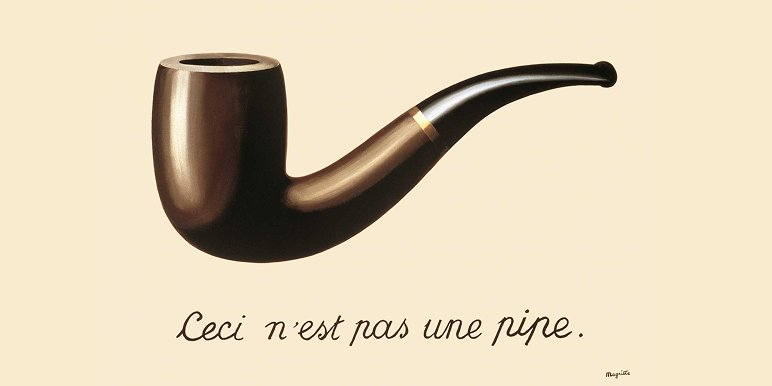

In [3]:

Image(filename=str(RAW_DIR / 'La_trahison_des_images.png'), width=600)


## Market overview

In [4]:

quote_summary = prices.groupby('product').agg(
    avg_mid=('mid_price', 'mean'),
    std_mid=('mid_price', 'std'),
    avg_spread=('spread', 'mean'),
    avg_top_depth=('top_depth', 'mean'),
)
trade_summary = trades.groupby('symbol').agg(
    trade_count=('quantity', 'size'),
    total_traded_qty=('quantity', 'sum'),
    active_trade_timestamps=('timestamp', 'nunique'),
)
summary = quote_summary.join(trade_summary, how='left').fillna(0)
display(summary.round(3).sort_values('avg_mid'))


,avg_mid,std_mid,avg_spread,avg_top_depth,trade_count,total_traded_qty,active_trade_timestamps
product,,,,,,,
VEV_6000,0.500,0.000,1.000,22.478,284,1002,279
VEV_6500,0.500,0.000,1.000,15.481,284,1002,279
VEV_5500,6.641,1.739,1.150,22.175,267,937,262
VEV_5400,15.952,3.429,1.381,21.741,225,787,220
VEV_5300,46.760,6.228,2.107,20.263,121,420,119
VEV_5200,95.549,9.664,2.888,22.536,18,63,18
VEV_5100,166.805,12.743,4.296,19.298,1,1,1
VEV_5000,255.022,14.376,6.043,15.405,1,1,1
VEV_4500,750.110,15.640,15.853,8.950,1,1,1


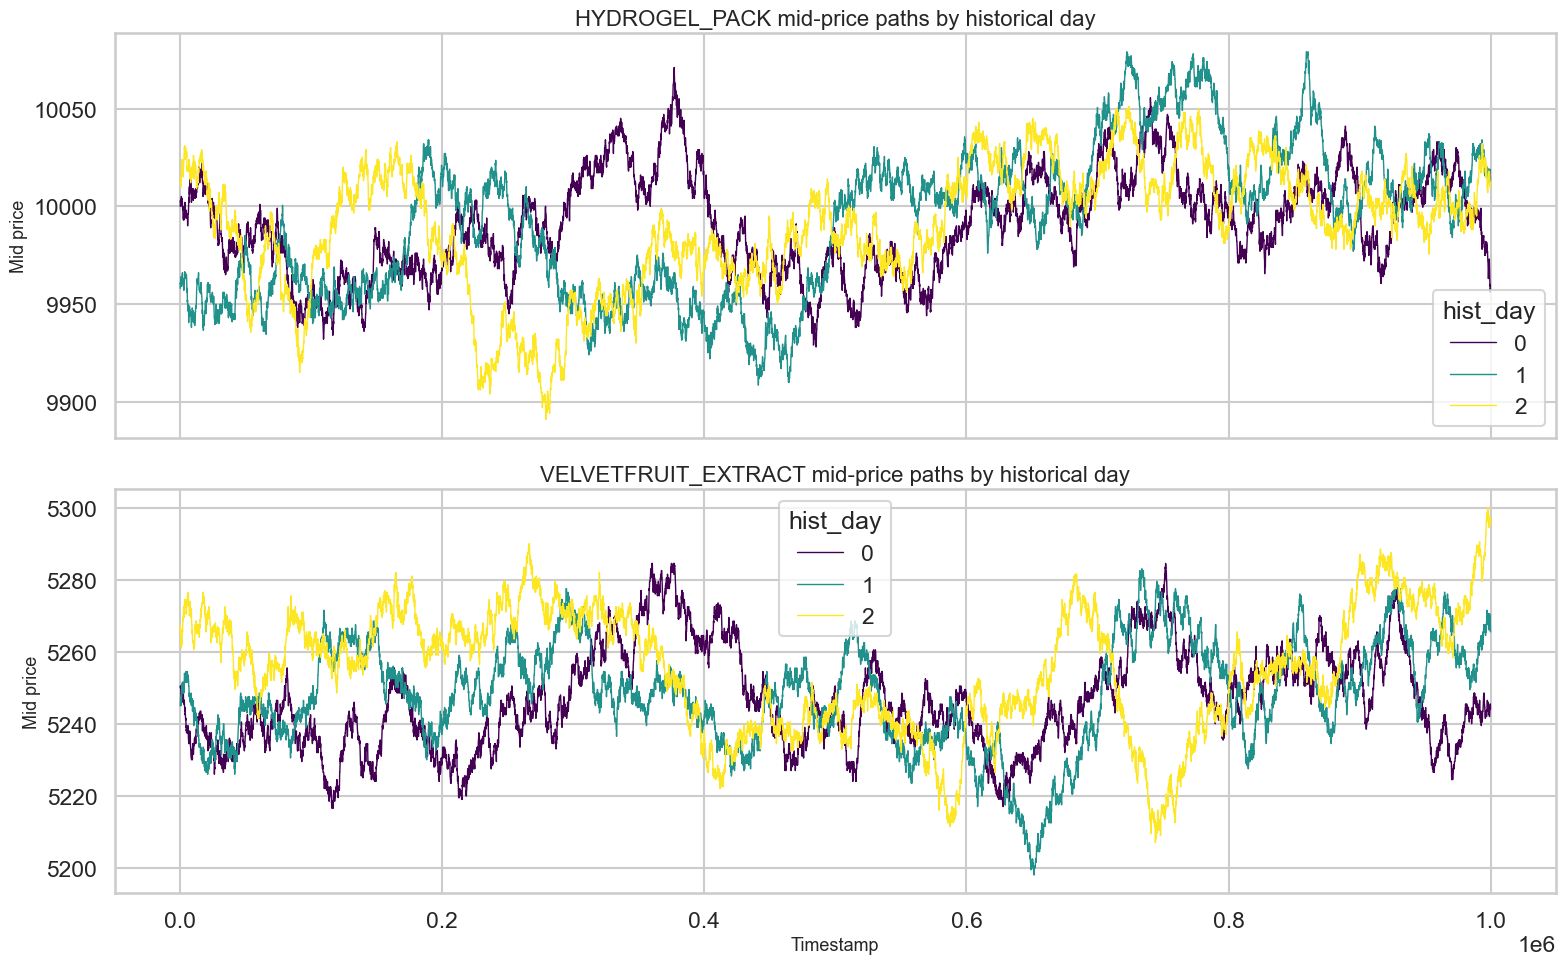

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
for ax, product in zip(axes, ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']):
    subset = prices[prices['product'] == product]
    sns.lineplot(data=subset, x='timestamp', y='mid_price', hue='hist_day', palette='viridis', ax=ax, linewidth=1)
    ax.set_title(f'{product} mid-price paths by historical day')
    ax.set_ylabel('Mid price')
    ax.legend(title='hist_day')
axes[-1].set_xlabel('Timestamp')
plt.tight_layout()
savefig('round3_underlying_price_paths.png')
plt.show()


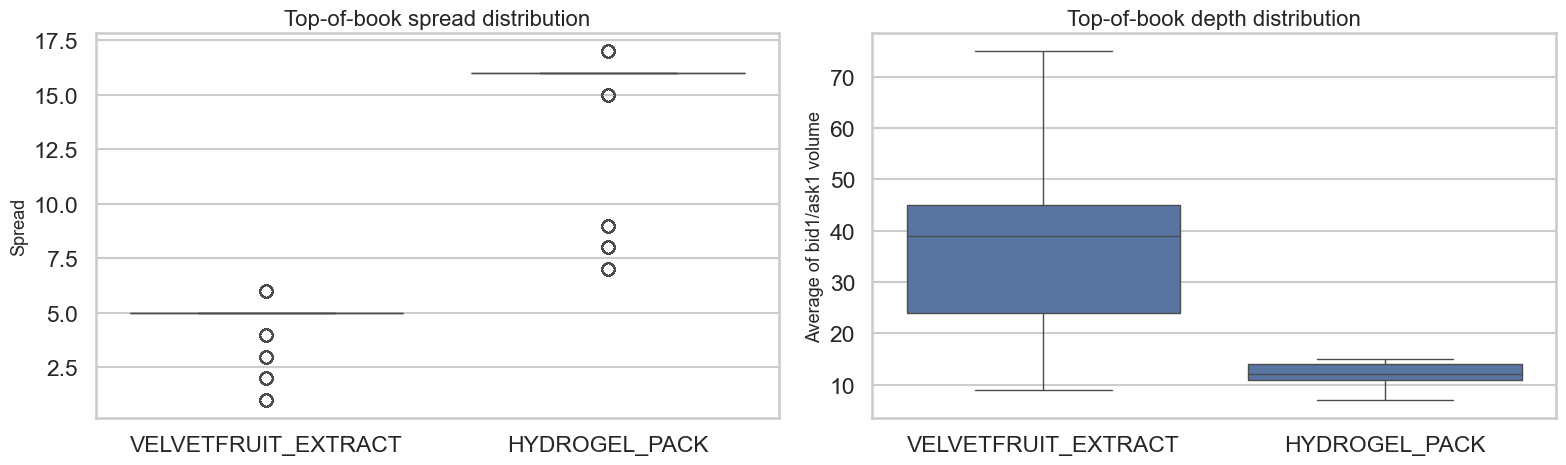

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
underlying_subset = prices[prices['product'].isin(['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT'])]
sns.boxplot(data=underlying_subset, x='product', y='spread', ax=axes[0])
axes[0].set_title('Top-of-book spread distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Spread')

sns.boxplot(data=underlying_subset, x='product', y='top_depth', ax=axes[1])
axes[1].set_title('Top-of-book depth distribution')
axes[1].set_xlabel('')
axes[1].set_ylabel('Average of bid1/ask1 volume')
plt.tight_layout()
savefig('round3_underlying_liquidity_boxplots.png')
plt.show()


Imbalance signal by bucket. Positive values mean bid-heavy books tend to be followed by upward moves.

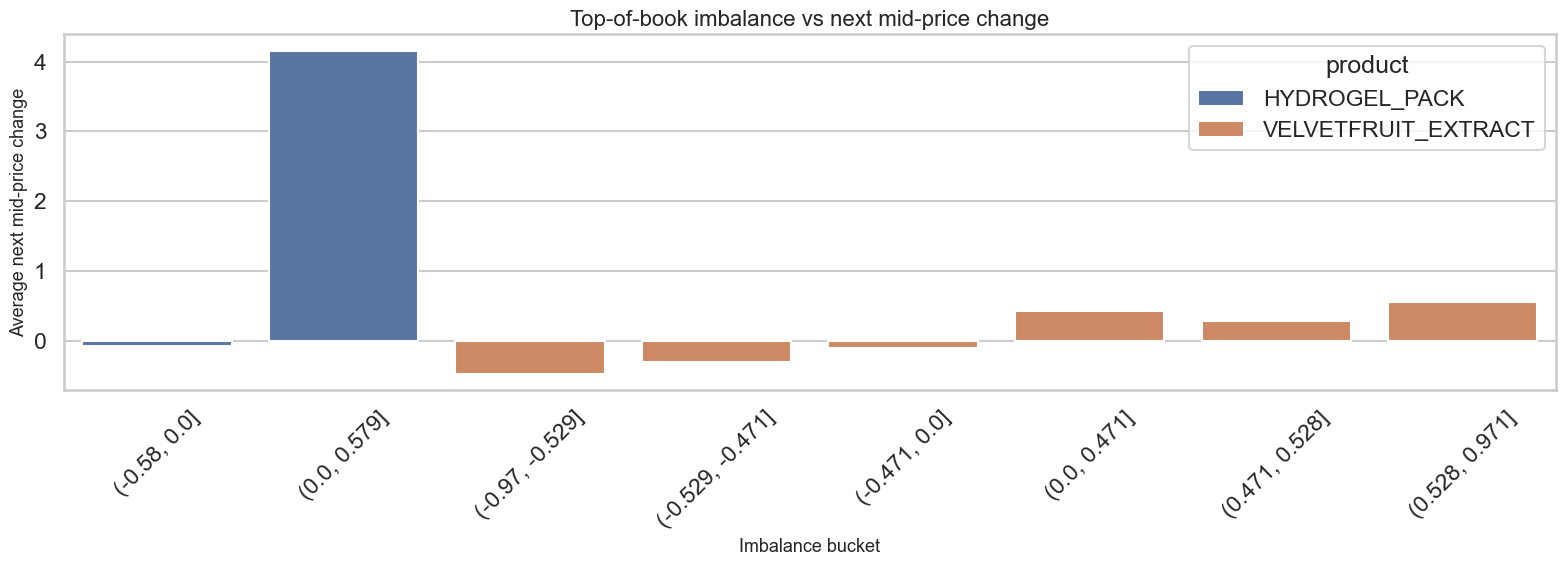

In [7]:

imbalance_rows = []
for product in ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']:
    df = prices[prices['product'] == product].sort_values(['hist_day', 'timestamp']).copy()
    df['imbalance'] = (df['bid_volume_1'] - df['ask_volume_1']) / (df['bid_volume_1'] + df['ask_volume_1'])
    df['next_mid_change'] = df.groupby('hist_day')['mid_price'].shift(-1) - df['mid_price']
    df = df.dropna(subset=['imbalance', 'next_mid_change'])
    try:
        df['bucket'] = pd.qcut(df['imbalance'], 10, duplicates='drop')
    except ValueError:
        df['bucket'] = pd.cut(df['imbalance'], bins=10)
    grouped = df.groupby('bucket', observed=False)['next_mid_change'].mean().reset_index()
    grouped['bucket_label'] = grouped['bucket'].astype(str)
    grouped['product'] = product
    imbalance_rows.append(grouped[['product', 'bucket_label', 'next_mid_change']])
imbalance_plot = pd.concat(imbalance_rows, ignore_index=True)
display(Markdown('Imbalance signal by bucket. Positive values mean bid-heavy books tend to be followed by upward moves.'))
fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=imbalance_plot, x='bucket_label', y='next_mid_change', hue='product', ax=ax)
ax.set_title('Top-of-book imbalance vs next mid-price change')
ax.set_xlabel('Imbalance bucket')
ax.set_ylabel('Average next mid-price change')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
savefig('round3_imbalance_signal.png')
plt.show()



### Interpretation for the delta-1 products

- `HYDROGEL_PACK` looks suitable for fairly conservative market-making or anchored mean reversion: it is wide, reasonably deep, and short-horizon returns reverse slightly.
- `VELVETFRUIT_EXTRACT` is the cleaner signal product. It is much tighter than `HYDROGEL_PACK`, has more depth, and its order-book imbalance contains useful directional information.
- The two underlyings are basically unrelated at the return level, so they should be modeled independently.


In [8]:

underlying_wide = prices.pivot_table(index=['hist_day', 'timestamp'], columns='product', values='mid_price')
underlying_rets = underlying_wide.groupby(level=0).diff()
print('Mid-price correlation:', round(underlying_wide['HYDROGEL_PACK'].corr(underlying_wide['VELVETFRUIT_EXTRACT']), 4))
print('Return correlation:', round(underlying_rets['HYDROGEL_PACK'].corr(underlying_rets['VELVETFRUIT_EXTRACT']), 4))


Mid-price correlation: 0.0967
Return correlation: 0.006


## Voucher surface

In [9]:

extrinsic_summary = options.groupby('product').agg(
    strike=('strike', 'first'),
    avg_mid=('mid_price', 'mean'),
    avg_intrinsic=('intrinsic', 'mean'),
    avg_extrinsic=('extrinsic', 'mean'),
    min_extrinsic=('extrinsic', 'min'),
    max_extrinsic=('extrinsic', 'max'),
    avg_spread=('spread', 'mean'),
).sort_values('strike')
display(extrinsic_summary.round(3))


,strike,avg_mid,avg_intrinsic,avg_extrinsic,min_extrinsic,max_extrinsic,avg_spread
product,,,,,,,
VEV_4000,4000,1250.110,1250.098,0.012,-7.0,7.0,20.813
VEV_4500,4500,750.110,750.098,0.011,-6.0,5.5,15.853
VEV_5000,5000,255.022,250.098,4.924,-0.5,11.5,6.043
VEV_5100,5100,166.805,150.098,16.707,4.5,29.5,4.296
VEV_5200,5200,95.549,50.098,45.450,21.5,67.5,2.888
VEV_5300,5300,46.760,0.000,46.760,26.5,65.5,2.107
VEV_5400,5400,15.952,0.000,15.952,6.5,27.0,1.381
VEV_5500,5500,6.641,0.000,6.641,2.5,12.5,1.150
VEV_6000,6000,0.500,0.000,0.500,0.5,0.5,1.000


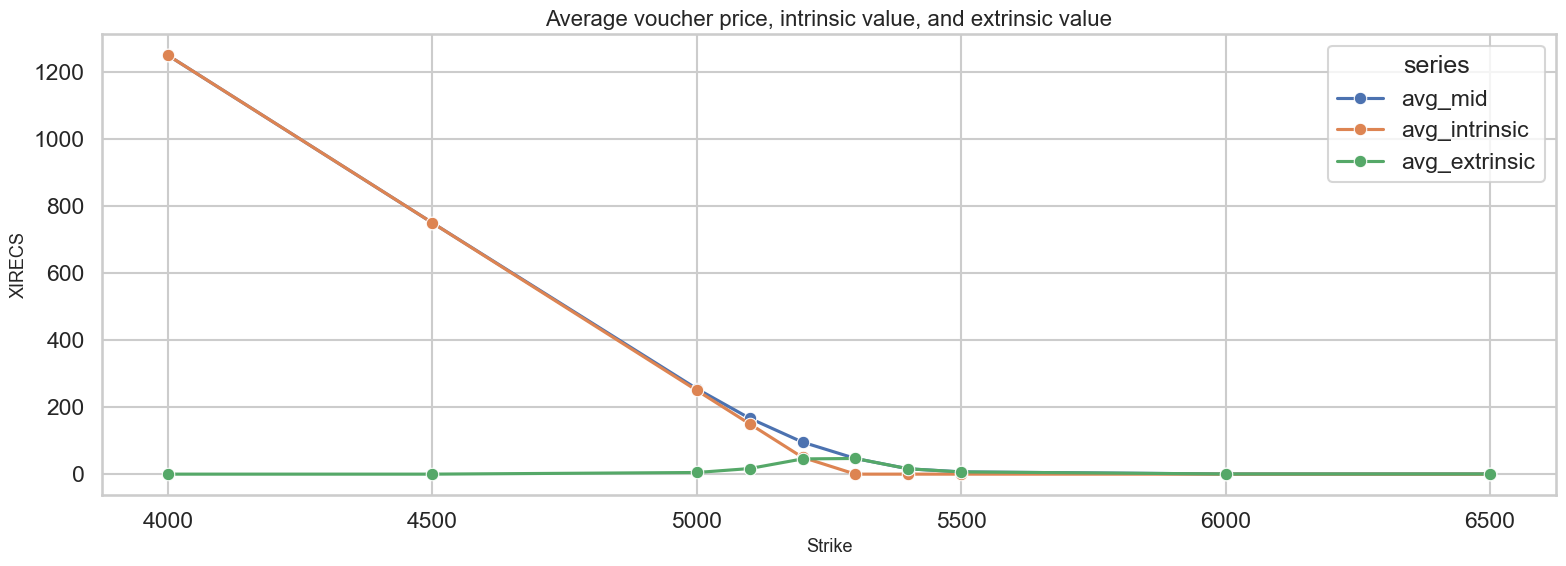

In [10]:

fig, ax = plt.subplots(figsize=(16, 6))
plot_df = extrinsic_summary.reset_index().melt(
    id_vars=['product', 'strike'],
    value_vars=['avg_mid', 'avg_intrinsic', 'avg_extrinsic'],
    var_name='series',
    value_name='value',
)
sns.lineplot(data=plot_df, x='strike', y='value', hue='series', marker='o', ax=ax)
ax.set_title('Average voucher price, intrinsic value, and extrinsic value')
ax.set_xlabel('Strike')
ax.set_ylabel('XIRECS')
plt.tight_layout()
savefig('round3_option_intrinsic_extrinsic.png')
plt.show()


In [11]:

viol_mon = 0
viol_conv = 0
for (_, _), grp in options.groupby(['hist_day', 'timestamp']):
    grp = grp.sort_values('strike')
    c = grp['mid_price'].to_numpy()
    k = grp['strike'].to_numpy()
    if np.any(np.diff(c) > 1e-12):
        viol_mon += 1
    slopes = np.diff(c) / np.diff(k)
    if np.any(np.diff(slopes) < -1e-12):
        viol_conv += 1
print('Monotonicity violations:', viol_mon)
print('Convexity violations:', viol_conv)


Monotonicity violations: 0
Convexity violations: 0


In [12]:

fit_rows = []
for day in sorted(options['hist_day'].unique()):
    ts_values = np.sort(options.loc[options['hist_day'] == day, 'timestamp'].unique())
    for ts in ts_values[::20]:
        grp = options[(options['hist_day'] == day) & (options['timestamp'] == ts)].sort_values('strike')
        S = float(grp['S'].iloc[0])
        K = grp['strike'].to_numpy(dtype=float)
        mkt = grp['mid_price'].to_numpy(dtype=float)
        model = bs_matrix(S, K, T_MAP[day], SIGMA_GRID)
        errs = ((model - mkt[None, :]) ** 2).mean(axis=1)
        best_idx = int(np.argmin(errs))
        best_sigma = float(SIGMA_GRID[best_idx])
        for product, strike, market_price, model_price in zip(grp['product'], grp['strike'], mkt, model[best_idx]):
            fit_rows.append((day, int(ts), best_sigma, product, int(strike), float(market_price), float(model_price), float(market_price - model_price)))
fit_sample = pd.DataFrame(fit_rows, columns=['hist_day', 'timestamp', 'sigma', 'product', 'strike', 'mid_price', 'model_price', 'residual'])

display(fit_sample.groupby('hist_day')['sigma'].agg(['mean', 'std', 'min', 'max']).round(4))


,mean,std,min,max
hist_day,,,,
0,0.2314,0.0041,0.2229,0.2415
1,0.2333,0.0053,0.2229,0.2453
2,0.2315,0.0065,0.2191,0.2453


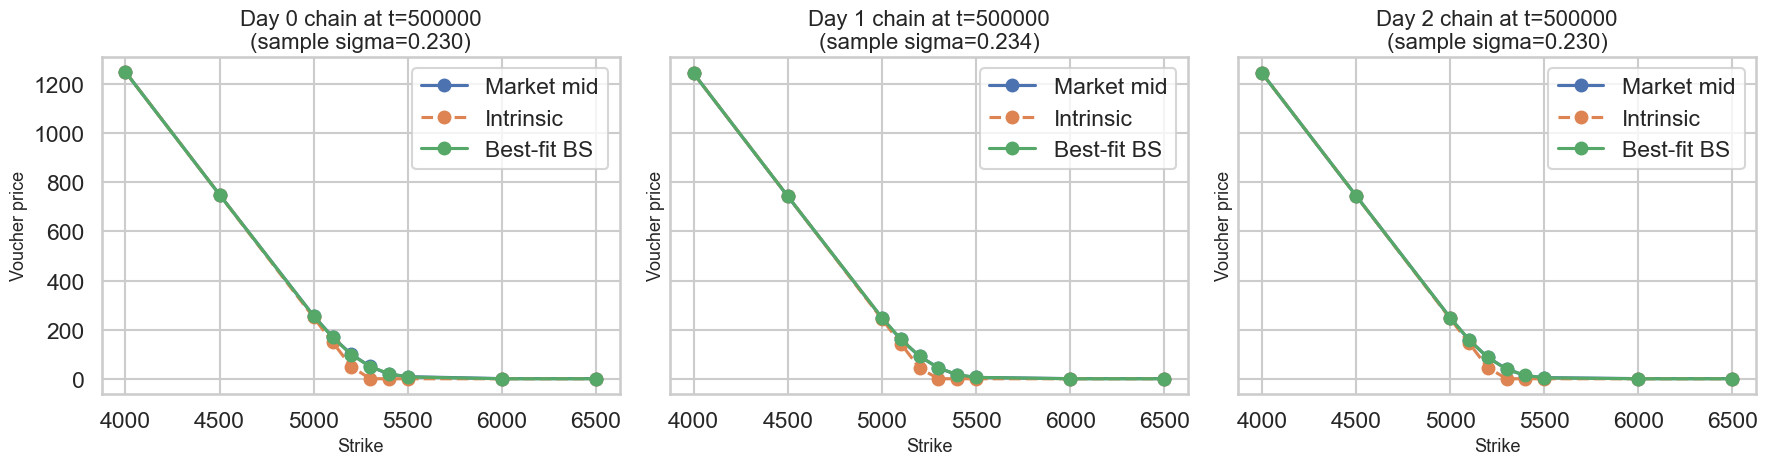

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, day in zip(axes, sorted(options['hist_day'].unique())):
    ts = int(np.sort(options.loc[options['hist_day'] == day, 'timestamp'].unique())[len(np.sort(options.loc[options['hist_day'] == day, 'timestamp'].unique())) // 2])
    chain = options[(options['hist_day'] == day) & (options['timestamp'] == ts)].sort_values('strike').copy()
    fit = fit_sample[(fit_sample['hist_day'] == day) & (fit_sample['timestamp'] == ts)].sort_values('strike').copy()
    ax.plot(chain['strike'], chain['mid_price'], marker='o', label='Market mid')
    ax.plot(chain['strike'], chain['intrinsic'], marker='o', linestyle='--', label='Intrinsic')
    ax.plot(fit['strike'], fit['model_price'], marker='o', label='Best-fit BS')
    ax.set_title(f'Day {day} chain at t={ts}\n(sample sigma={fit["sigma"].iloc[0]:.3f})')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Voucher price')
    ax.legend()
plt.tight_layout()
savefig('round3_option_chain_snapshots.png')
plt.show()


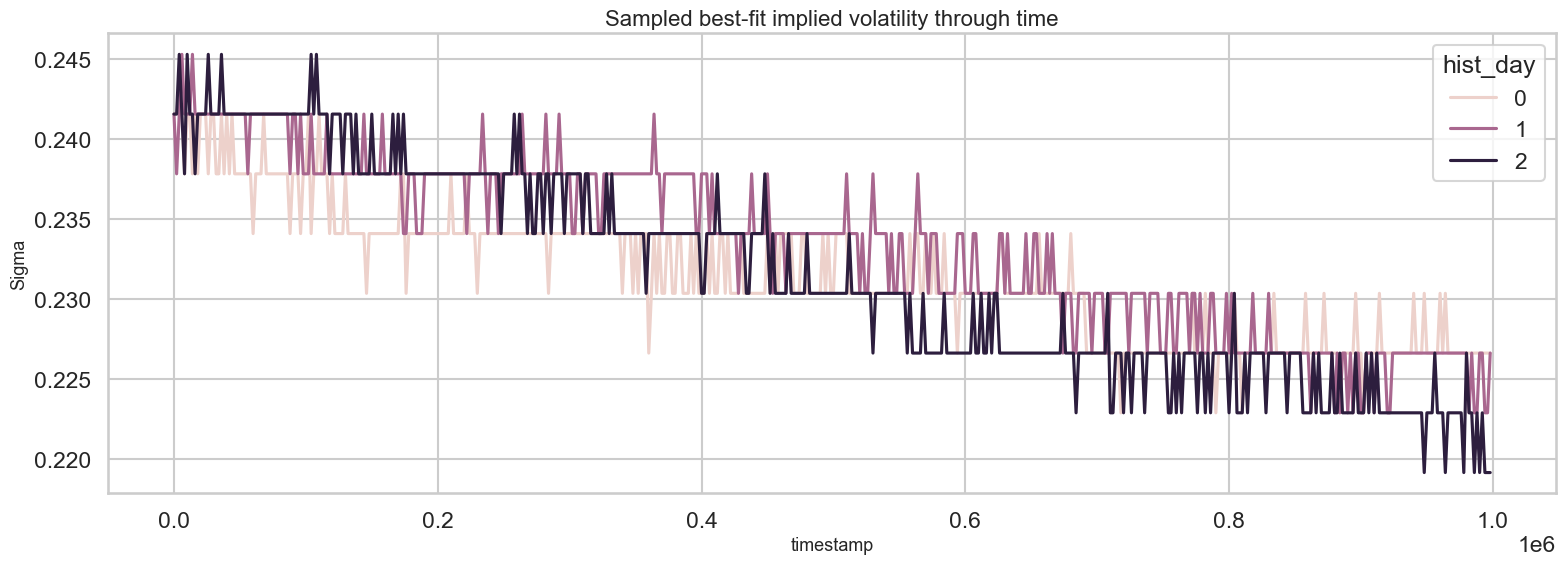

In [14]:

fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(data=fit_sample[['hist_day', 'timestamp', 'sigma']].drop_duplicates(), x='timestamp', y='sigma', hue='hist_day', ax=ax)
ax.set_title('Sampled best-fit implied volatility through time')
ax.set_ylabel('Sigma')
plt.tight_layout()
savefig('round3_sampled_implied_vol.png')
plt.show()


/var/folders/v1/x83lc1hn5hsfl25bdmxr5yt40000gn/T/ipykernel_40630/3145529428.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=residual_summary, x='product', y='mean', palette='coolwarm', ax=ax)


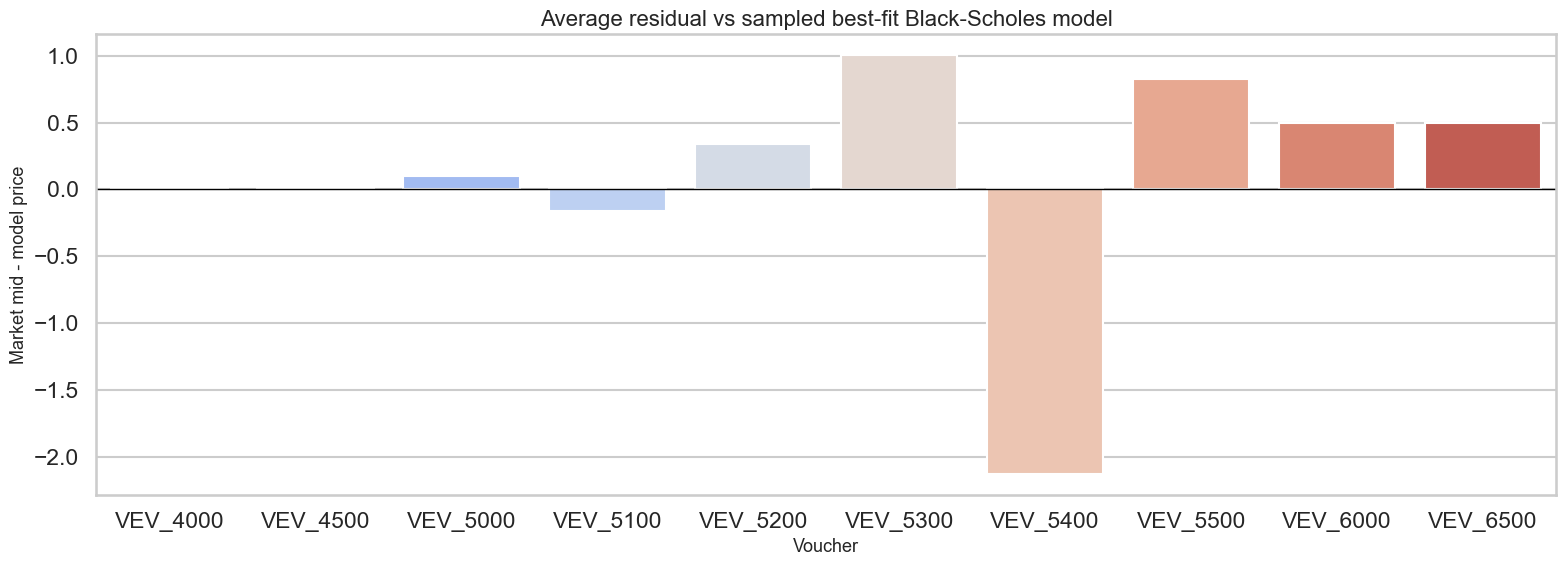

,product,mean,std,strike
0,VEV_4000,0.0137,0.8942,4000
1,VEV_4500,0.0073,0.8023,4500
2,VEV_5000,0.1031,0.5324,5000
3,VEV_5100,-0.1605,1.0827,5100
4,VEV_5200,0.3405,0.6363,5200
5,VEV_5300,1.0033,0.8004,5300
6,VEV_5400,-2.1319,0.8646,5400
7,VEV_5500,0.8269,0.4133,5500
8,VEV_6000,0.4990,0.0010,6000
9,VEV_6500,0.5000,0.0000,6500


In [15]:

residual_summary = fit_sample.groupby('product')['residual'].agg(mean='mean', std='std').reset_index()
residual_summary['strike'] = residual_summary['product'].str.split('_').str[1].astype(int)
residual_summary = residual_summary.sort_values('strike')
fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=residual_summary, x='product', y='mean', palette='coolwarm', ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Average residual vs sampled best-fit Black-Scholes model')
ax.set_xlabel('Voucher')
ax.set_ylabel('Market mid - model price')
plt.tight_layout()
savefig('round3_option_residuals.png')
plt.show()

display(residual_summary.round(4))


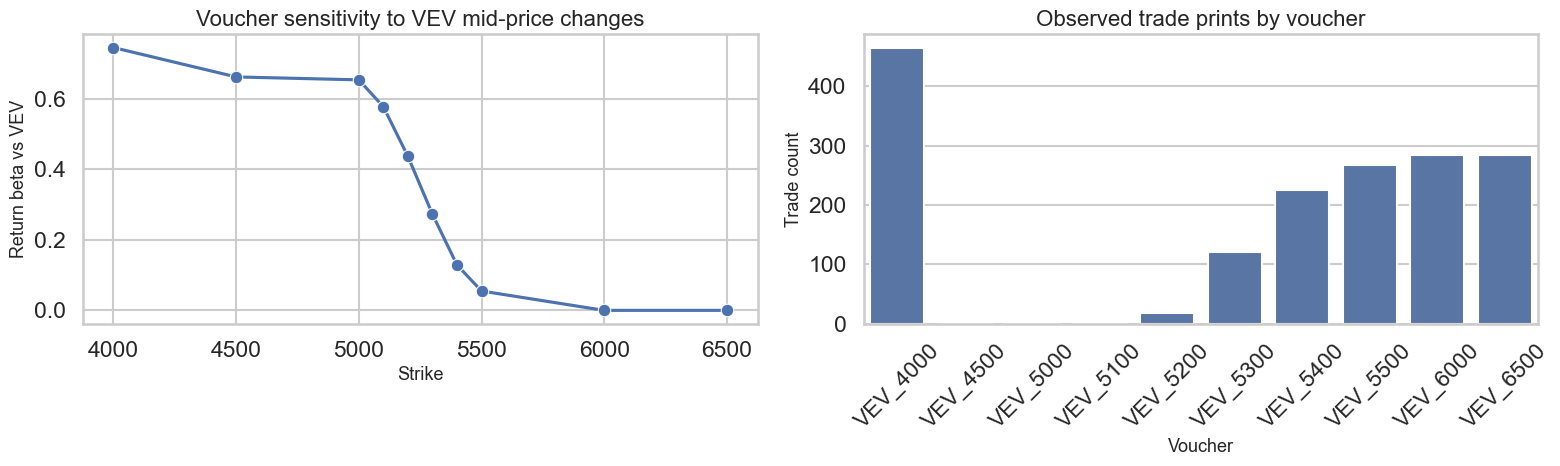

,product,strike,corr_with_vev,beta_to_vev,trade_count
0,VEV_4000,4000,0.5949,0.7451,464
1,VEV_4500,4500,0.5979,0.6618,1
2,VEV_5000,5000,0.7536,0.6535,1
3,VEV_5100,5100,0.7653,0.5773,1
4,VEV_5200,5200,0.7174,0.4367,18
5,VEV_5300,5300,0.6216,0.2727,121
6,VEV_5400,5400,0.5401,0.1289,225
7,VEV_5500,5500,0.3482,0.0549,267
8,VEV_6000,6000,NaN,0.0000,284
9,VEV_6500,6500,NaN,0.0000,284


In [16]:

wide = prices.pivot_table(index=['hist_day', 'timestamp'], columns='product', values='mid_price')
rets = wide.groupby(level=0).diff()
rows = []
under = rets['VELVETFRUIT_EXTRACT']
under_var = under.dropna().var()
for product in sorted([c for c in wide.columns if c.startswith('VEV_')]):
    pair = rets[[product]].join(under.rename('under')).dropna()
    corr = pair[product].corr(pair['under']) if pair[product].std() > 0 else np.nan
    beta = pair.cov().iloc[0, 1] / under_var if pair[product].std() > 0 else 0.0
    rows.append((product, int(product.split('_')[1]), corr, beta))
option_beta = pd.DataFrame(rows, columns=['product', 'strike', 'corr_with_vev', 'beta_to_vev'])
trade_counts = trades.groupby('symbol').size().rename('trade_count').reset_index().rename(columns={'symbol': 'product'})
option_beta = option_beta.merge(trade_counts, on='product', how='left').fillna({'trade_count': 0})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=option_beta, x='strike', y='beta_to_vev', marker='o', ax=axes[0])
axes[0].set_title('Voucher sensitivity to VEV mid-price changes')
axes[0].set_ylabel('Return beta vs VEV')
axes[0].set_xlabel('Strike')

sns.barplot(data=option_beta.sort_values('strike'), x='product', y='trade_count', ax=axes[1])
axes[1].set_title('Observed trade prints by voucher')
axes[1].set_xlabel('Voucher')
axes[1].set_ylabel('Trade count')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
savefig('round3_option_beta_and_trade_counts.png')
plt.show()

display(option_beta.round(4))



### Interpretation for the vouchers

- The surface is internally consistent. Static arbitrage checks do not flag simple monotonicity or convexity errors.
- Sampled implied vol is stable around roughly 23 percent under the TTE mapping assumed above. That is a strong sign that a simple volatility-based fair-value model should already be competitive.
- The residual chart is the important trading clue. The cleanest repeated pattern is that `VEV_5400` is underpriced relative to the fitted surface, while `VEV_5300` and `VEV_5500` tend to be rich.
- `VEV_6000` and `VEV_6500` are effectively pinned at the 0/1 quote floor. They are more like fixed-price lottery tickets than continuously repriced options.
- Trade prints are sparse for several strikes, so quote-based valuation should dominate print-based valuation there.


## Manual challenge

In [17]:

reserves = np.arange(670, 921, 5)
avg_candidates = np.arange(750, 901, 5)
opt_rows = []
for avg_b2 in avg_candidates:
    best_pair = None
    best_pnl = -1.0
    for b1 in reserves:
        for b2 in reserves:
            if b2 < b1:
                continue
            pnl = manual_expected_pnl(int(b1), int(b2), int(avg_b2))
            if pnl > best_pnl:
                best_pnl = pnl
                best_pair = (int(b1), int(b2))
    opt_rows.append((int(avg_b2), best_pair[0], best_pair[1], best_pnl))
manual_opt = pd.DataFrame(opt_rows, columns=['avg_b2', 'best_b1', 'best_b2', 'expected_pnl'])
display(manual_opt.head(10))


,avg_b2,best_b1,best_b2,expected_pnl
0,750,750,835,4165.0
1,755,750,835,4165.0
2,760,750,835,4165.0
3,765,750,835,4165.0
4,770,750,835,4165.0
5,775,750,835,4165.0
6,780,750,835,4165.0
7,785,750,835,4165.0
8,790,750,835,4165.0
9,795,750,835,4165.0


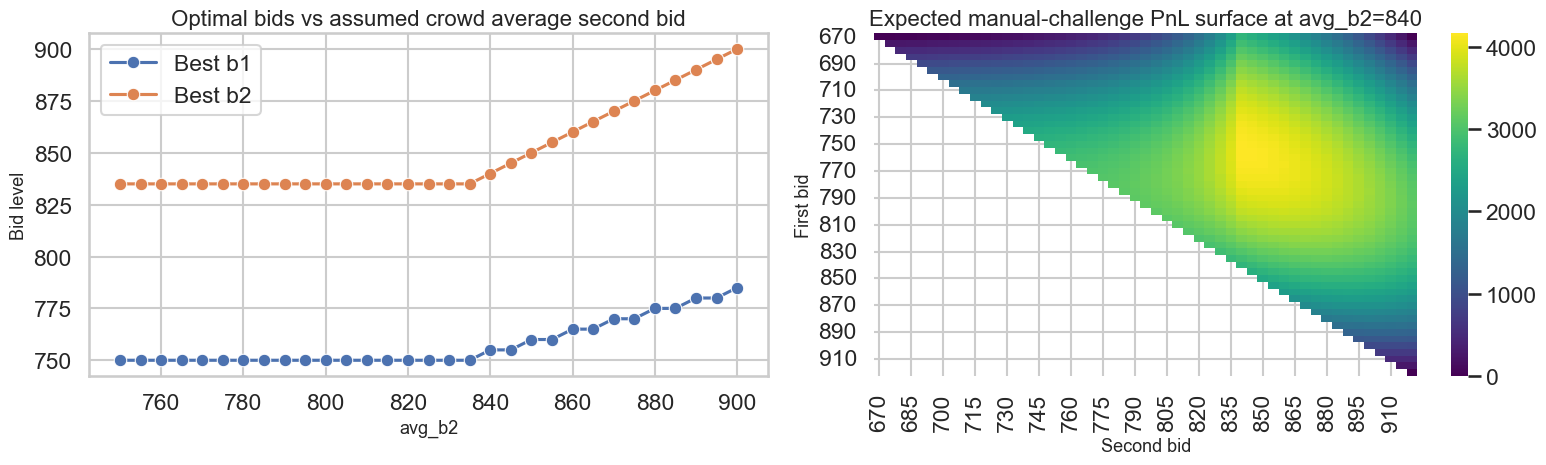

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=manual_opt, x='avg_b2', y='best_b1', marker='o', label='Best b1', ax=axes[0])
sns.lineplot(data=manual_opt, x='avg_b2', y='best_b2', marker='o', label='Best b2', ax=axes[0])
axes[0].set_title('Optimal bids vs assumed crowd average second bid')
axes[0].set_ylabel('Bid level')

avg_example = 840
surface = []
for b1 in reserves:
    for b2 in reserves:
        if b2 >= b1:
            surface.append((int(b1), int(b2), manual_expected_pnl(int(b1), int(b2), avg_example)))
surface_df = pd.DataFrame(surface, columns=['b1', 'b2', 'expected_pnl'])
pivot = surface_df.pivot(index='b1', columns='b2', values='expected_pnl')
sns.heatmap(pivot, cmap='viridis', ax=axes[1])
axes[1].set_title(f'Expected manual-challenge PnL surface at avg_b2={avg_example}')
axes[1].set_xlabel('Second bid')
axes[1].set_ylabel('First bid')
plt.tight_layout()
savefig('round3_manual_challenge.png')
plt.show()



### Manual challenge interpretation

- If your second bid is at or above the crowd average, the simple discrete uniform model favors approximately **(750, 835)**.
- As the crowd average second bid rises above 835, the robust optimum shifts upward with it, for example toward **(755, 840)** and then **(775, 880)**.
- The first bid mainly monetizes low reserves with high margin. The second bid is the volume bid and becomes the main point of fragility when the penalty turns on.
- If you have no good estimate for the crowd average, this is a coordination problem rather than a pure reserve-price problem.



## Actionable trading ideas for `trader.py`

1. Treat `HYDROGEL_PACK` as a classic mean-reversion / market-making product with a fairly stable anchor and useful imbalance signal.
2. Use `VELVETFRUIT_EXTRACT` as the clean base process for voucher valuation. It is tighter, deeper, and should be the state variable that drives the option model.
3. Build a simple voucher fair-value engine first. A stable-volatility call model is already a good baseline here.
4. Rank vouchers by residual to model fair value rather than by raw price level. The repeated cross-sectional pattern matters more than absolute prices.
5. Avoid over-trusting market-trade prints in illiquid strikes. For some vouchers, the historical trade series is nearly empty even though quotes are present at every timestamp.
6. Keep the implementation modular: one block for delta-1 products, one block for voucher valuation and residual ranking, and one block for cross-product risk controls.

The next practical step is to turn the fair-value and residual sections of this notebook into a lightweight signal pipeline for `round_3/submission/trader.py`.
